In [1]:
# Credit Card Complaints - Data Exploration & Cleaning
# This notebook loads, explores, cleans, and prepares credit card complaint data for BigQuery

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Analysis date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries imported successfully!
Pandas version: 3.0.5
Analysis date: 2026-10-02 14:14:15


In [2]:
# Load raw credit card data
print("Loading credit card complaint data...")
credit_data = pd.read_csv("../data/raw/credit_card.csv")

print(f"✓ Data loaded successfully!")
print(f"Shape: {credit_data.shape[0]:,} rows × {credit_data.shape[1]} columns")
print(f"Memory usage: {credit_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nFirst 5 rows:")
credit_data.head()

Loading credit card complaint data...
✓ Data loaded successfully!
Shape: 246,212 rows × 16 columns
Memory usage: 360.58 MB

First 5 rows:


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2023-08-17T20:21:27.000Z,Credit card,General-purpose credit card or charge card,Fees or interest,Problem with fees,NaN,NaN,JPMORGAN CHASE & CO.,CA,93401,NaN,Referral,2023-08-30T16:45:03.000Z,Closed with explanation,Yes,7476202
1,2023-08-24T14:52:37.000Z,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute about a purchase on your statement,NaN,NaN,Comerica,MO,63112,NaN,Referral,2023-09-06T21:11:32.000Z,Closed with explanation,Yes,7510127
2,2023-08-24T16:49:33.000Z,Credit card,General-purpose credit card or charge card,Problem when making payments,Problem during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,"CITIBANK, N.A.",NY,11230,NaN,Referral,2023-08-25T13:26:07.000Z,Closed with explanation,Yes,7457201
3,2023-08-25T00:08:24.000Z,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute about a purchase on your statement,NaN,NaN,"Block, Inc.",FL,32514,NaN,Web,2023-08-25T00:46:36.000Z,Closed with explanation,Yes,7452304
4,2023-08-25T01:50:48.000Z,Credit card,General-purpose credit card or charge card,Problem with a company's investigation into an existing problem,Was not notified of investigation status or results,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,112XX,NaN,Web,2023-08-25T01:53:36.000Z,Closed with non-monetary relief,Yes,7451765


In [3]:
# Inspect column names and data types
print("Column Information:")
print("=" * 80)
print(f"\nColumns ({len(credit_data.columns)}):")
for i, col in enumerate(credit_data.columns, 1):
    dtype = credit_data[col].dtype
    null_count = credit_data[col].isnull().sum()
    null_pct = (null_count / len(credit_data)) * 100
    print(f"{i:2d}. {col:45s} | {str(dtype):10s} | Nulls: {null_count:6,} ({null_pct:5.1f}%)")

print("\n" + "=" * 80)
print("\nData Types Summary:")
credit_data.dtypes.value_counts()

Column Information:

Columns (16):
 1. Date received                                 | str        | Nulls:      0 (  0.0%)
 2. Product                                       | str        | Nulls:      0 (  0.0%)
 3. Sub-product                                   | str        | Nulls:      0 (  0.0%)
 4. Issue                                         | str        | Nulls:      0 (  0.0%)
 5. Sub-issue                                     | str        | Nulls:    235 (  0.1%)
 6. Consumer complaint narrative                  | str        | Nulls: 137,849 ( 56.0%)
 7. Company public response                       | str        | Nulls: 129,340 ( 52.5%)
 8. Company                                       | str        | Nulls:      0 (  0.0%)
 9. State                                         | str        | Nulls:    971 (  0.4%)
10. ZIP code                                      | str        | Nulls:    179 (  0.1%)
11. Tags                                          | str        | Nulls: 210,248 ( 8

str      15
int64     1
Name: count, dtype: int64

In [4]:
# Data Quality Assessment
print("DATA QUALITY REPORT")
print("=" * 80)

# 1. Missing values
print("\n1. MISSING VALUES ANALYSIS")
print("-" * 80)
missing = credit_data.isnull().sum()
missing_pct = (missing / len(credit_data)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Count', ascending=False)

print(missing_df[missing_df['Missing_Count'] > 0].to_string(index=False))

# 2. Duplicates
print(f"\n2. DUPLICATE RECORDS")
print("-" * 80)
duplicates = credit_data.duplicated().sum()
print(f"Total duplicate rows: {duplicates:,}")

# Check for duplicate complaint IDs (should be unique)
duplicate_ids = credit_data['Complaint ID'].duplicated().sum()
print(f"Duplicate Complaint IDs: {duplicate_ids:,}")

# 3. Data ranges
print(f"\n3. DATA RANGES")
print("-" * 80)
print(f"Date range: {credit_data['Date received'].min()} to {credit_data['Date received'].max()}")
print(f"Complaint IDs range: {credit_data['Complaint ID'].min():,} to {credit_data['Complaint ID'].max():,}")

DATA QUALITY REPORT

1. MISSING VALUES ANALYSIS
--------------------------------------------------------------------------------
                      Column  Missing_Count  Missing_Percentage
                        Tags         210248           85.393076
Consumer complaint narrative         137849           55.987929
     Company public response         129340           52.531964
                       State            971            0.394376
                   Sub-issue            235            0.095446
                    ZIP code            179            0.072702

2. DUPLICATE RECORDS
--------------------------------------------------------------------------------
Total duplicate rows: 0
Duplicate Complaint IDs: 0

3. DATA RANGES
--------------------------------------------------------------------------------
Date range: 2023-08-17T20:21:27.000Z to 2026-08-18T20:22:48.000Z
Complaint IDs range: 7,451,765 to 25,507,655


TOP ISSUES IN CREDIT CARD COMPLAINTS

Total unique issues: 15

Top 15 Issues:
Issue
Problem with a purchase shown on your statement                    58514
Incorrect information on your report                               32075
Getting a credit card                                              30409
Problem with a company's investigation into an existing problem    26343
Other features, terms, or problems                                 24644
Fees or interest                                                   21884
Closing your account                                               15555
Problem when making payments                                       13022
Advertising and marketing, including promotional offers             9227
Trouble using your card                                             8256
Struggling to pay your bill                                         3105
Improper use of your report                                         2275
Credit monitoring or identity theft prot

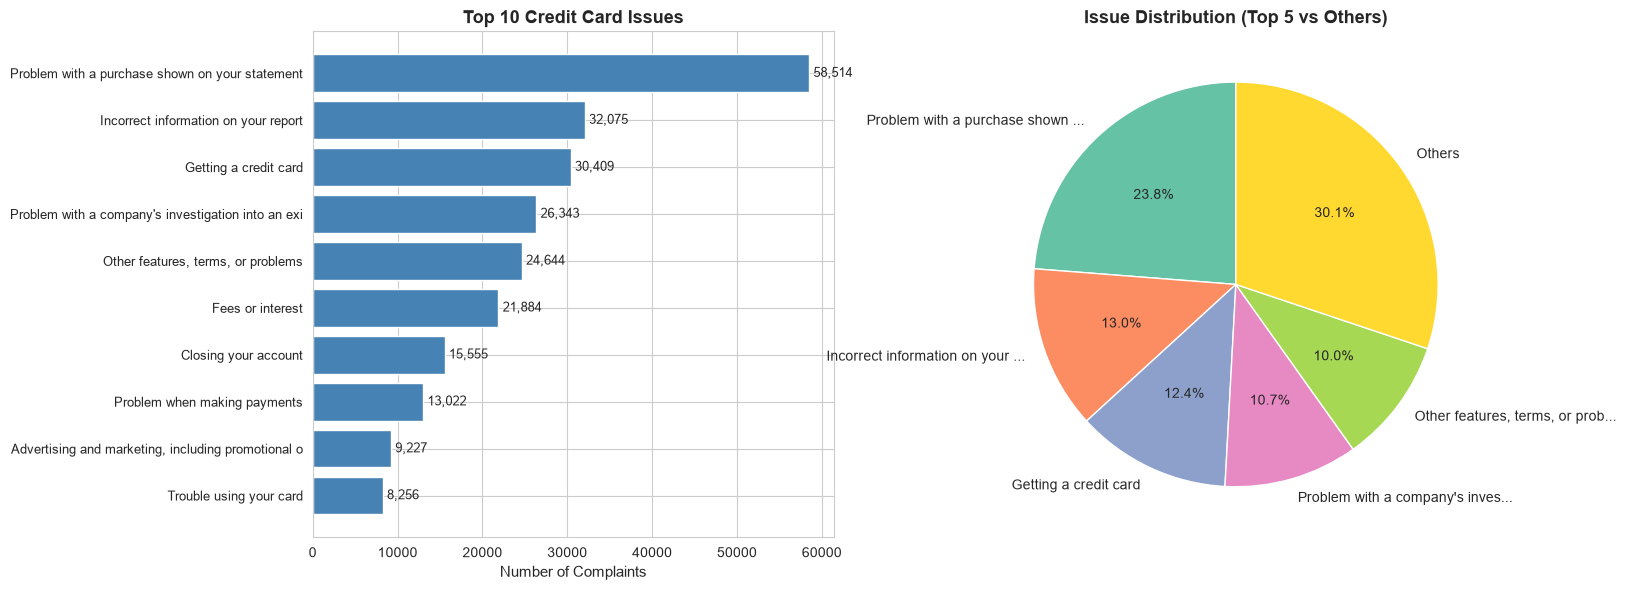

In [5]:
# Exploratory Data Analysis - Top Issues
print("TOP ISSUES IN CREDIT CARD COMPLAINTS")
print("=" * 80)

issue_counts = credit_data['Issue'].value_counts()
print(f"\nTotal unique issues: {len(issue_counts)}")
print(f"\nTop 15 Issues:")
print(issue_counts.head(15))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart - Top 10 issues
top_issues = issue_counts.head(10)
ax1.barh(range(len(top_issues)), top_issues.values, color='steelblue')
ax1.set_yticks(range(len(top_issues)))
ax1.set_yticklabels([label[:50] for label in top_issues.index], fontsize=9)
ax1.set_xlabel('Number of Complaints', fontsize=11)
ax1.set_title('Top 10 Credit Card Issues', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(top_issues.values):
    ax1.text(v + 500, i, f'{v:,}', va='center', fontsize=9)

# Pie chart - Top 5 issues vs Others
top5 = issue_counts.head(5)
other_count = issue_counts[5:].sum()
pie_data = list(top5.values) + [other_count]
pie_labels = [label[:30] + '...' if len(label) > 30 else label for label in top5.index] + ['Others']
colors = sns.color_palette('Set2', len(pie_data))

ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax2.set_title('Issue Distribution (Top 5 vs Others)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

TOP COMPANIES BY COMPLAINT VOLUME

Total unique companies: 805

Top 20 Companies:
Company
CAPITAL ONE FINANCIAL CORPORATION         27768
CITIBANK, N.A.                            24488
SYNCHRONY FINANCIAL                       18954
EQUIFAX, INC.                             18409
JPMORGAN CHASE & CO.                      17518
TRANSUNION INTERMEDIATE HOLDINGS, INC.    17199
Experian Information Solutions Inc.       16184
AMERICAN EXPRESS COMPANY                  13645
BANK OF AMERICA, NATIONAL ASSOCIATION     12526
Bread Financial Holdings, Inc.             8609
WELLS FARGO & COMPANY                      7916
GOLDMAN SACHS BANK USA                     6854
DISCOVER BANK                              6783
BARCLAYS BANK DELAWARE                     6290
U.S. BANCORP                               4081
TD BANK US HOLDING COMPANY                 3509
NAVY FEDERAL CREDIT UNION                  3282
CLGF Holdco 1, LLC                         2653
Chime Financial Inc                        185

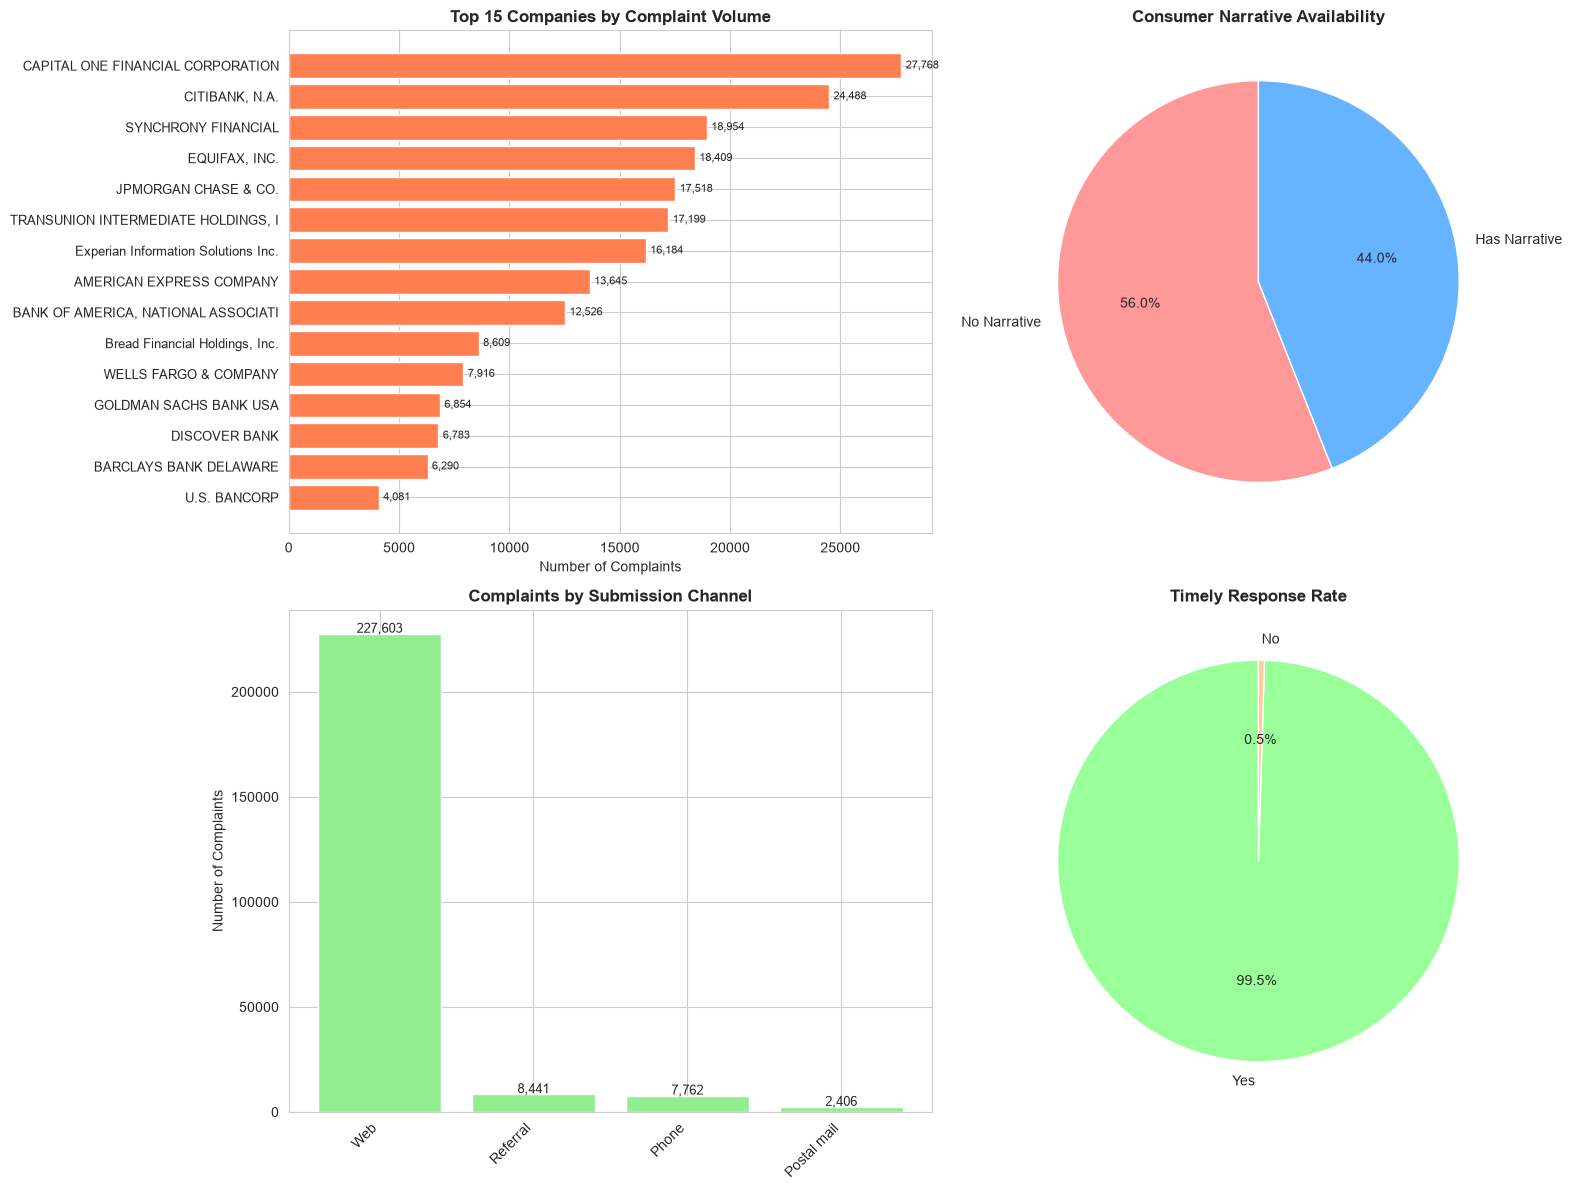


✓ Consumer narratives available: 108,363 (44.0%)


In [6]:
# Exploratory Data Analysis - Top Companies
print("TOP COMPANIES BY COMPLAINT VOLUME")
print("=" * 80)

company_counts = credit_data['Company'].value_counts()
print(f"\nTotal unique companies: {len(company_counts)}")
print(f"\nTop 20 Companies:")
print(company_counts.head(20))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 15 companies bar chart
ax = axes[0, 0]
top_companies = company_counts.head(15)
ax.barh(range(len(top_companies)), top_companies.values, color='coral')
ax.set_yticks(range(len(top_companies)))
ax.set_yticklabels([c[:35] for c in top_companies.index], fontsize=9)
ax.set_xlabel('Number of Complaints', fontsize=10)
ax.set_title('Top 15 Companies by Complaint Volume', fontsize=12, fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(top_companies.values):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=8)

# 2. Consumer narrative availability
ax = axes[0, 1]
narrative_counts = credit_data['Consumer complaint narrative'].notna().value_counts()
labels = ['No Narrative', 'Has Narrative']
colors_narrative = ['#ff9999', '#66b3ff']
ax.pie(narrative_counts.values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_narrative)
ax.set_title('Consumer Narrative Availability', fontsize=12, fontweight='bold')

# 3. Submission channels
ax = axes[1, 0]
submission_counts = credit_data['Submitted via'].value_counts()
ax.bar(range(len(submission_counts)), submission_counts.values, color='lightgreen')
ax.set_xticks(range(len(submission_counts)))
ax.set_xticklabels(submission_counts.index, rotation=45, ha='right')
ax.set_ylabel('Number of Complaints', fontsize=10)
ax.set_title('Complaints by Submission Channel', fontsize=12, fontweight='bold')
for i, v in enumerate(submission_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# 4. Timely response rate
ax = axes[1, 1]
timely_counts = credit_data['Timely response?'].value_counts()
ax.pie(timely_counts.values, labels=timely_counts.index, autopct='%1.1f%%', startangle=90, colors=['#99ff99', '#ffcc99'])
ax.set_title('Timely Response Rate', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Consumer narratives available: {credit_data['Consumer complaint narrative'].notna().sum():,} ({(credit_data['Consumer complaint narrative'].notna().sum()/len(credit_data)*100):.1f}%)")

TEMPORAL ANALYSIS
Date range: 2023-08-17 20:21:27+00:00 to 2026-08-18 20:22:48+00:00
Total months covered: 37


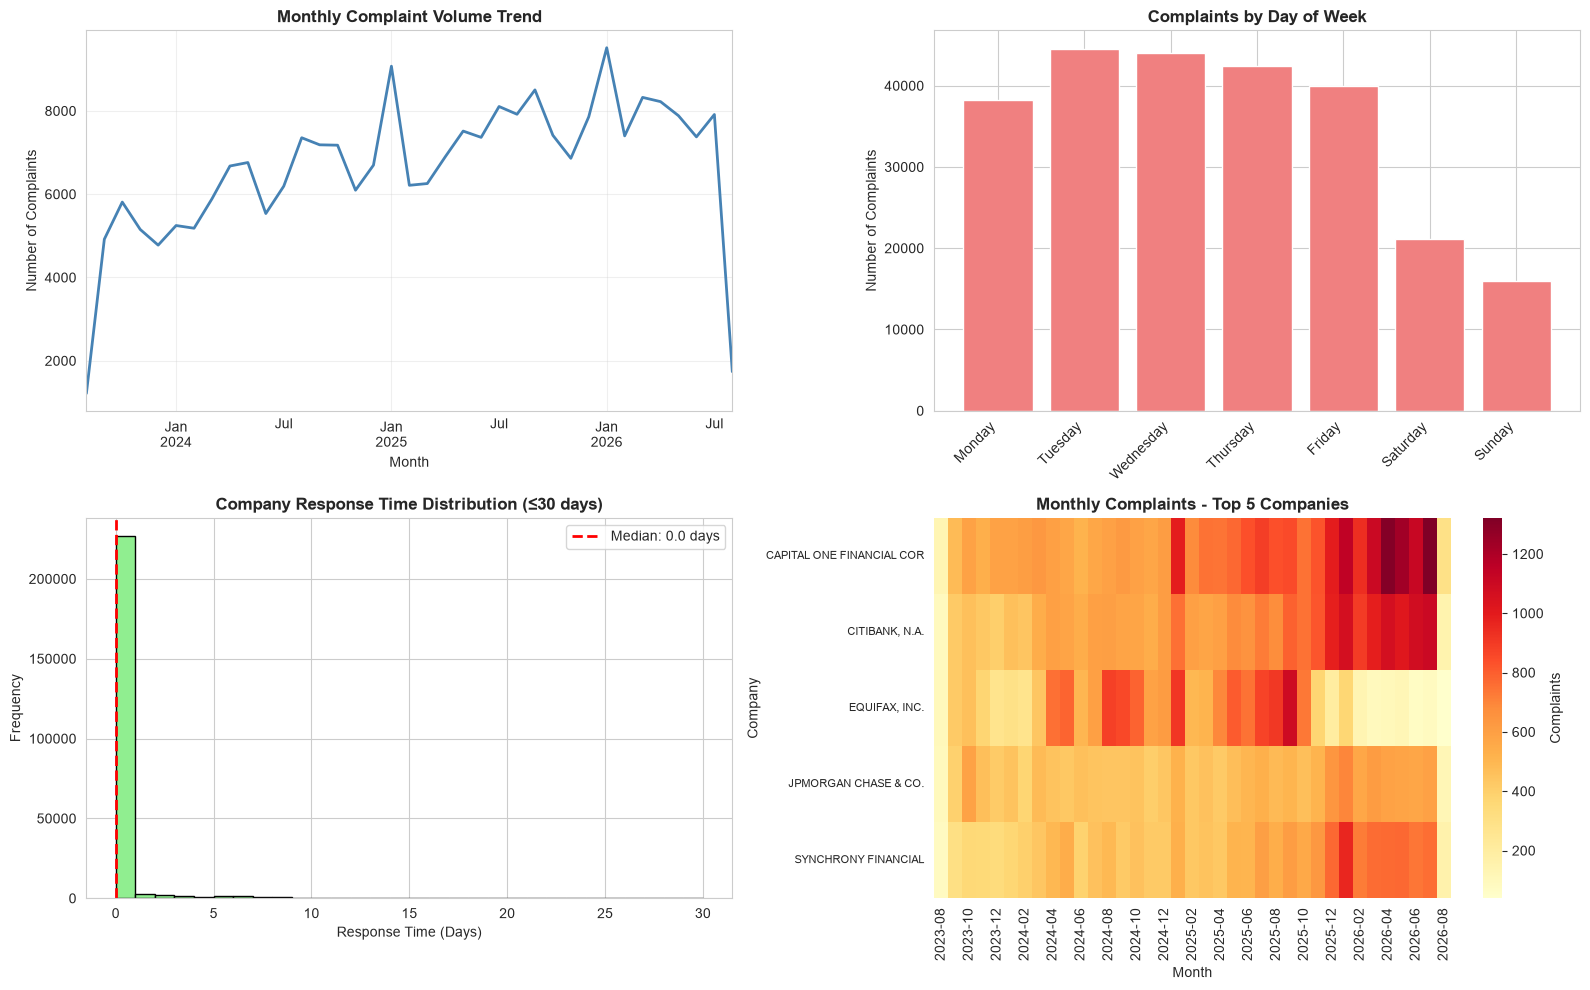


Response Time Statistics:
  Mean: 1.23 days
  Median: 0.00 days
  Min: 0.00 days
  Max: 445.00 days


In [7]:
# Time Series Analysis
print("TEMPORAL ANALYSIS")
print("=" * 80)

# Convert date columns
credit_data['date_received_parsed'] = pd.to_datetime(credit_data['Date received'])
credit_data['date_sent_parsed'] = pd.to_datetime(credit_data['Date sent to company'])

# Extract time components
credit_data['year'] = credit_data['date_received_parsed'].dt.year
credit_data['month'] = credit_data['date_received_parsed'].dt.month
credit_data['year_month'] = credit_data['date_received_parsed'].dt.to_period('M')

# Monthly complaint trend
monthly_counts = credit_data.groupby('year_month').size()

print(f"Date range: {credit_data['date_received_parsed'].min()} to {credit_data['date_received_parsed'].max()}")
print(f"Total months covered: {len(monthly_counts)}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Monthly trend
ax = axes[0, 0]
monthly_counts.plot(ax=ax, color='steelblue', linewidth=2)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Number of Complaints', fontsize=10)
ax.set_title('Monthly Complaint Volume Trend', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# 2. Day of week distribution
credit_data['day_of_week'] = credit_data['date_received_parsed'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = credit_data['day_of_week'].value_counts().reindex(day_order)
ax = axes[0, 1]
ax.bar(range(len(day_counts)), day_counts.values, color='lightcoral')
ax.set_xticks(range(len(day_counts)))
ax.set_xticklabels(day_counts.index, rotation=45, ha='right')
ax.set_ylabel('Number of Complaints', fontsize=10)
ax.set_title('Complaints by Day of Week', fontsize=12, fontweight='bold')

# 3. Response time analysis
credit_data['response_time_days'] = (credit_data['date_sent_parsed'] - credit_data['date_received_parsed']).dt.days
ax = axes[1, 0]
response_times = credit_data['response_time_days'].dropna()
ax.hist(response_times[response_times <= 30], bins=30, color='lightgreen', edgecolor='black')
ax.set_xlabel('Response Time (Days)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title('Company Response Time Distribution (≤30 days)', fontsize=12, fontweight='bold')
ax.axvline(response_times.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {response_times.median():.1f} days')
ax.legend()

# 4. Top companies by month (heatmap for top 5)
top_5_companies = company_counts.head(5).index
company_month_pivot = credit_data[credit_data['Company'].isin(top_5_companies)].groupby(['year_month', 'Company']).size().unstack(fill_value=0)
ax = axes[1, 1]
sns.heatmap(company_month_pivot.T, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Complaints'}, fmt='d')
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Company', fontsize=10)
ax.set_title('Monthly Complaints - Top 5 Companies', fontsize=12, fontweight='bold')
ax.set_yticklabels([c[:25] for c in company_month_pivot.columns], rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nResponse Time Statistics:")
print(f"  Mean: {response_times.mean():.2f} days")
print(f"  Median: {response_times.median():.2f} days")
print(f"  Min: {response_times.min():.2f} days")
print(f"  Max: {response_times.max():.2f} days")

GEOGRAPHIC DISTRIBUTION

Total unique states: 60

Top 20 States by Complaint Volume:
State
CA    33065
TX    29963
FL    24231
NY    18336
IL    11792
GA    10377
PA     9115
NJ     8868
VA     7864
NC     7226
OH     5540
MD     5448
AZ     5108
MI     5076
MA     4787
WA     4415
TN     3432
CO     3386
NV     3259
IN     3065
Name: count, dtype: int64


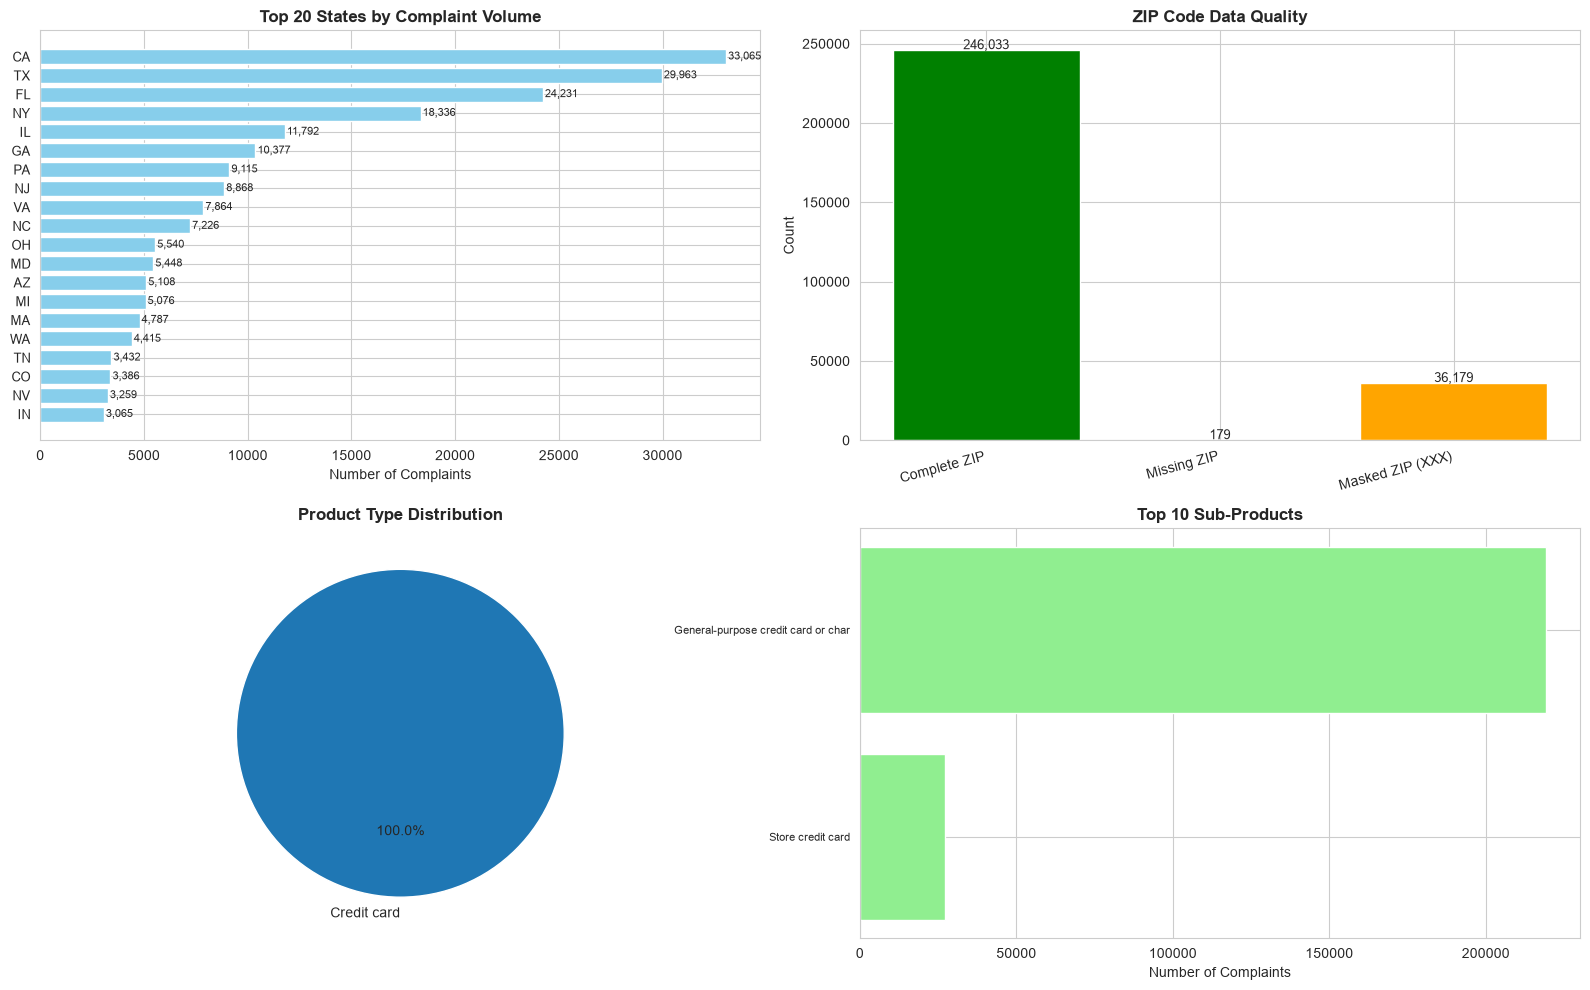

In [8]:
# Geographic Analysis
print("GEOGRAPHIC DISTRIBUTION")
print("=" * 80)

state_counts = credit_data['State'].value_counts()
print(f"\nTotal unique states: {len(state_counts)}")
print(f"\nTop 20 States by Complaint Volume:")
print(state_counts.head(20))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Top 20 states
ax = axes[0, 0]
top_states = state_counts.head(20)
ax.barh(range(len(top_states)), top_states.values, color='skyblue')
ax.set_yticks(range(len(top_states)))
ax.set_yticklabels(top_states.index, fontsize=9)
ax.set_xlabel('Number of Complaints', fontsize=10)
ax.set_title('Top 20 States by Complaint Volume', fontsize=12, fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(top_states.values):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=8)

# 2. ZIP code data quality
ax = axes[0, 1]
zip_quality = {
    'Complete ZIP': credit_data['ZIP code'].notna().sum(),
    'Missing ZIP': credit_data['ZIP code'].isna().sum(),
    'Masked ZIP (XXX)': credit_data['ZIP code'].astype(str).str.contains('XX', na=False).sum()
}
ax.bar(zip_quality.keys(), zip_quality.values(), color=['green', 'red', 'orange'])
ax.set_ylabel('Count', fontsize=10)
ax.set_title('ZIP Code Data Quality', fontsize=12, fontweight='bold')
ax.set_xticklabels(zip_quality.keys(), rotation=15, ha='right')
for i, (k, v) in enumerate(zip_quality.items()):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# 3. Product type distribution
ax = axes[1, 0]
product_counts = credit_data['Product'].value_counts()
ax.pie(product_counts.values, labels=product_counts.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Product Type Distribution', fontsize=12, fontweight='bold')

# 4. Sub-product distribution (top 10)
ax = axes[1, 1]
subproduct_counts = credit_data['Sub-product'].value_counts().head(10)
ax.barh(range(len(subproduct_counts)), subproduct_counts.values, color='lightgreen')
ax.set_yticks(range(len(subproduct_counts)))
ax.set_yticklabels([p[:35] for p in subproduct_counts.index], fontsize=8)
ax.set_xlabel('Number of Complaints', fontsize=10)
ax.set_title('Top 10 Sub-Products', fontsize=12, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [9]:
# DATA CLEANING - Step 1: Create cleaned copy
print("STARTING DATA CLEANING PROCESS")
print("=" * 80)

# Create a copy for cleaning
credit_cleaned = credit_data.copy()
initial_rows = len(credit_cleaned)

print(f"Initial dataset: {initial_rows:,} rows")
print("\nCleaning steps:")
print("-" * 80)

STARTING DATA CLEANING PROCESS
Initial dataset: 246,212 rows

Cleaning steps:
--------------------------------------------------------------------------------


In [ ]:
# DATA CLEANING - Step 2: Standardize column names to snake_case
print("1. Standardizing column names to snake_case...")

# Create column name mapping
column_mapping = {
    'Date received': 'date_received',
    'Product': 'product',
    'Sub-product': 'sub_product',
    'Issue': 'issue',
    'Sub-issue': 'sub_issue',
    'Consumer complaint narrative': 'consumer_complaint_narrative',
    'Company public response': 'company_public_response',
    'Company': 'company',
    'State': 'state',
    'ZIP code': 'zip_code',
    'Tags': 'tags',
    'Submitted via': 'submitted_via',
    'Date sent to company': 'date_sent_to_company',
    'Company response to consumer': 'company_response',
    'Timely response?': 'timely_response',
    'Complaint ID': 'complaint_id'
}

credit_cleaned = credit_cleaned.rename(columns=column_mapping)
print(f"✓ Column names standardized")
print(f"  New columns: {list(credit_cleaned.columns)}")

In [ ]:
# DATA CLEANING - Step 3: Convert date columns to proper datetime
print("\n2. Converting date columns to datetime format...")

# Parse dates
credit_cleaned['date_received'] = pd.to_datetime(credit_cleaned['date_received'], errors='coerce')
credit_cleaned['date_sent_to_company'] = pd.to_datetime(credit_cleaned['date_sent_to_company'], errors='coerce')

# Check for any parsing errors
date_errors = credit_cleaned['date_received'].isna().sum()
print(f"✓ Date columns converted")
print(f"  Date parsing errors: {date_errors}")
print(f"  Date range: {credit_cleaned['date_received'].min().date()} to {credit_cleaned['date_received'].max().date()}")

In [ ]:
# DATA CLEANING - Step 4: Clean text fields
print("\n3. Cleaning text fields...")

def clean_text(text):
    """Clean text by stripping whitespace and converting empty strings to None."""
    if pd.isna(text):
        return None
    text = str(text).strip()
    return text if text and text != '' else None

# Text columns to clean
text_columns = [
    'product', 'sub_product', 'issue', 'sub_issue',
    'consumer_complaint_narrative', 'company_public_response',
    'company', 'state', 'submitted_via', 'company_response',
    'timely_response', 'tags'
]

for col in text_columns:
    if col in credit_cleaned.columns:
        credit_cleaned[col] = credit_cleaned[col].apply(clean_text)

print(f"✓ Text fields cleaned")
print(f"  Cleaned {len(text_columns)} text columns")

In [ ]:
# DATA CLEANING - Step 5: Handle ZIP codes
print("\n4. Processing ZIP codes...")

def clean_zip_code(zip_code):
    """Clean ZIP code - keep first 5 digits only."""
    if pd.isna(zip_code):
        return None
    zip_str = str(zip_code).strip()
    # Remove XX masks
    if 'XX' in zip_str or 'xx' in zip_str:
        return None
    # Keep only first 5 digits
    digits = ''.join(filter(str.isdigit, zip_str))
    return digits[:5] if len(digits) >= 5 else None

credit_cleaned['zip_code'] = credit_cleaned['zip_code'].apply(clean_zip_code)

valid_zips = credit_cleaned['zip_code'].notna().sum()
print(f"✓ ZIP codes cleaned")
print(f"  Valid ZIP codes: {valid_zips:,} ({valid_zips/len(credit_cleaned)*100:.1f}%)")

In [ ]:
# DATA CLEANING - Step 6: Remove duplicates
print("\n5. Removing duplicate records...")

# Remove duplicates based on complaint_id (should be unique)
before_dedup = len(credit_cleaned)
credit_cleaned = credit_cleaned.drop_duplicates(subset=['complaint_id'], keep='first')
after_dedup = len(credit_cleaned)
removed = before_dedup - after_dedup

print(f"✓ Duplicates removed")
print(f"  Records removed: {removed:,}")
print(f"  Final record count: {after_dedup:,}")

In [ ]:
# DATA CLEANING - Step 7: Select and order final columns for BigQuery
print("\n6. Selecting final columns for BigQuery...")

# Define final schema for BigQuery
final_columns = [
    'complaint_id',
    'date_received',
    'date_sent_to_company',
    'product',
    'sub_product',
    'issue',
    'sub_issue',
    'consumer_complaint_narrative',
    'company',
    'state',
    'zip_code',
    'submitted_via',
    'company_response',
    'timely_response',
    'company_public_response',
    'tags'
]

credit_cleaned = credit_cleaned[final_columns]

print(f"✓ Final schema defined")
print(f"  Columns: {len(final_columns)}")
print(f"  Rows: {len(credit_cleaned):,}")

In [11]:
# Final Data Quality Summary
print("\n" + "=" * 80)
print("CLEANED DATA SUMMARY")
print("=" * 80)

print(f"\nDataset Shape: {credit_cleaned.shape}")
print(f"Date Range: {credit_cleaned['date_received'].min().date()} to {credit_cleaned['date_received'].max().date()}")
print(f"Unique Companies: {credit_cleaned['company'].nunique():,}")
print(f"Unique Issues: {credit_cleaned['issue'].nunique()}")
print(f"Records with Narratives: {credit_cleaned['consumer_complaint_narrative'].notna().sum():,} ({credit_cleaned['consumer_complaint_narrative'].notna().sum()/len(credit_cleaned)*100:.1f}%)")

print("\n" + "-" * 80)
print("Missing Values in Cleaned Data:")
print("-" * 80)
missing_cleaned = credit_cleaned.isnull().sum()
missing_pct_cleaned = (missing_cleaned / len(credit_cleaned)) * 100
missing_summary = pd.DataFrame({
    'Column': missing_cleaned.index,
    'Missing': missing_cleaned.values,
    'Percentage': missing_pct_cleaned.values
}).sort_values('Missing', ascending=False)
print(missing_summary[missing_summary['Missing'] > 0].to_string(index=False))

print("\n" + "-" * 80)
print("Sample of Cleaned Data:")
print("-" * 80)
credit_cleaned.head()


CLEANED DATA SUMMARY

Dataset Shape: (246212, 23)


KeyError: 'date_received'

In [10]:
# Export cleaned data
import os

print("EXPORTING CLEANED DATA")
print("=" * 80)

# Create output directory if it doesn't exist
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

# Export to CSV
output_path = os.path.join(output_dir, 'credit_card_cleaned.csv')
credit_cleaned.to_csv(output_path, index=False)

print(f"✓ Data exported successfully!")
print(f"  Output path: {output_path}")
print(f"  File size: {os.path.getsize(output_path) / 1024**2:.2f} MB")
print(f"  Total records: {len(credit_cleaned):,}")

print("\n" + "=" * 80)
print("CREDIT CARD DATA CLEANING COMPLETE!")
print("=" * 80)
print(f"\nNext steps:")
print(f"1. Review the cleaned data at: {output_path}")
print(f"2. Run the mortgage cleaning notebook")
print(f"3. Combine both datasets if needed")
print(f"4. Production pipeline: python -m ingestion.clean && python -m ingestion.load_bigquery")

EXPORTING CLEANED DATA
✓ Data exported successfully!
  Output path: ../../../data/credit_card_cleaned.csv
  File size: 218.10 MB
  Total records: 246,212

CREDIT CARD DATA CLEANING COMPLETE!

Next steps:
1. Review the cleaned data at: ../../../data/credit_card_cleaned.csv
2. Run the mortgage cleaning notebook
3. Combine both datasets if needed
4. Load to BigQuery using: ingestion/load_bigquery.py
